# INTRODUCCIÓN
# Este proyecto busca clasificar imágenes del dataset CIFAR-100 utilizando una red neuronal multicapa (MLP).
Recordemos que en un proyecto como este lo ideal es utilizar CNN, ya que, en CIFAR-100 contiene imagenes complejas (arboles, trenes, personas, flores, etc).
Estos objetos tienen patrones espaciales que un MLP no puede reconocer bien llevando a cabo un bajo porcentaje de precision, ya que convierte la imagen en un vector plano.
Una CNN, en cambio, mantiene la estructura de la imagen y usa filtros que detectan:

*   Bordes
*   Texturas
*   Formas
*   Combinaciones de estas a diferentes niveles

Aun asi utilizaremos MLP, ya que, nos servira para aprender conceptos fundamentales de redes neuronales como:

*   Cómo ajustar hiperparámetros
*   Cómo usar callbacks
*   Cómo evaluar métricas
*   Cómo comparar modelos
*   Cómo funciona TensorFlow/Keras

y (porque la rubrica pide MLP)


# Se utilizará TensorFlow/Keras con técnicas de optimización, evaluación de métricas y visualización con TensorBoard.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import datetime

CARGA Y PREPROCESAMIENTO DE DATOS

In [ ]:

(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train_flat = X_train.reshape((X_train.shape[0], -1))  # (50000, 3072)
X_test_flat = X_test.reshape((X_test.shape[0], -1))      # (10000, 3072)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Visualización de muestras

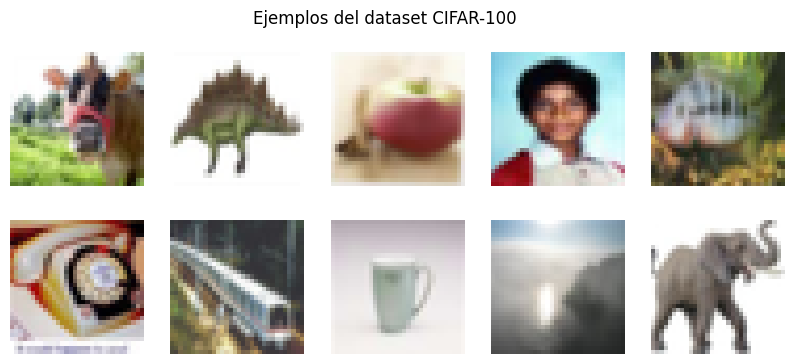

In [ ]:

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.suptitle("Ejemplos del dataset CIFAR-100")
plt.show()


DEFINICIÓN DEL MODELO MLP BASE

In [ ]:

def crear_modelo(activation='relu', optimizer='adam'):
    model = Sequential([
        Dense(512, activation=activation, input_shape=(3072,)),
        Dropout(0.3),
        Dense(256, activation=activation),
        Dropout(0.3),
        Dense(100, activation='softmax')
    ])
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


CALLBACKS

In [ ]:

log_dir = "logs/fit/base_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('mejor_modelo.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
callbacks = [tensorboard_callback, early_stop, checkpoint]

ENTRENAMIENTO DEL MODELO

In [ ]:

model = crear_modelo()
history = model.fit(
    X_train_flat, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.06360, saving model to mejor_modelo.h5


704/704 - 22s - 31ms/step - accuracy: 0.0337 - loss: 4.3676 - val_accuracy: 0.0636 - val_loss: 4.1409
Epoch 2/30

Epoch 2: val_accuracy improved from 0.06360 to 0.08100, saving model to mejor_modelo.h5


704/704 - 20s - 28ms/step - accuracy: 0.0558 - loss: 4.1575 - val_accuracy: 0.0810 - val_loss: 4.0279
Epoch 3/30

Epoch 3: val_accuracy improved from 0.08100 to 0.09160, saving model to mejor_modelo.h5


704/704 - 19s - 27ms/step - accuracy: 0.0672 - loss: 4.0744 - val_accuracy: 0.0916 - val_loss: 3.9703
Epoch 4/30

Epoch 4: val_accuracy improved from 0.09160 to 0.11280, saving model to mejor_modelo.h5


704/704 - 20s - 28ms/step - accuracy: 0.0724 - loss: 4.0259 - val_accuracy: 0.1128 - val_loss: 3.8738
Epoch 5/30

Epoch 5: val_accuracy improved from 0.11280 to 0.12260, saving model to mejor_modelo.h5


704/704 - 21s - 30ms/step - accuracy: 0.0812 - loss: 3.9907 - val_accuracy: 0.1226 - val_loss: 3.8557
Epoch 6/30

Epoch 6: val_accuracy did not improve from 0.12260
704/704 - 39s - 56ms/step - accuracy: 0.0844 - loss: 3.9643 - val_accuracy: 0.1176 - val_loss: 3.8611
Epoch 7/30

Epoch 7: val_accuracy did not improve from 0.12260
704/704 - 19s - 26ms/step - accuracy: 0.0869 - loss: 3.9452 - val_accuracy: 0.1122 - val_loss: 3.8716
Epoch 8/30

Epoch 8: val_accuracy did not improve from 0.12260
704/704 - 20s - 28ms/step - accuracy: 0.0912 - loss: 3.9144 - val_accuracy: 0.1144 - val_loss: 3.8541
Epoch 9/30

Epoch 9: val_accuracy did not improve from 0.12260
704/704 - 19s - 27ms/step - accuracy: 0.0937 - loss: 3.9094 - val_accuracy: 0.1212 - val_loss: 3.8284
Epoch 10/30

Epoch 10: val_accuracy improved from 0.12260 to 0.13140, saving model to mejor_modelo.h5


704/704 - 19s - 27ms/step - accuracy: 0.0947 - loss: 3.8843 - val_accuracy: 0.1314 - val_loss: 3.7912
Epoch 11/30

Epoch 11: val_accuracy did not improve from 0.13140
704/704 - 19s - 27ms/step - accuracy: 0.1003 - loss: 3.8719 - val_accuracy: 0.1238 - val_loss: 3.7837
Epoch 12/30

Epoch 12: val_accuracy did not improve from 0.13140
704/704 - 19s - 27ms/step - accuracy: 0.0978 - loss: 3.8713 - val_accuracy: 0.1300 - val_loss: 3.7798
Epoch 13/30

Epoch 13: val_accuracy improved from 0.13140 to 0.13160, saving model to mejor_modelo.h5


704/704 - 21s - 29ms/step - accuracy: 0.1018 - loss: 3.8594 - val_accuracy: 0.1316 - val_loss: 3.7653
Epoch 14/30

Epoch 14: val_accuracy improved from 0.13160 to 0.13640, saving model to mejor_modelo.h5


704/704 - 20s - 28ms/step - accuracy: 0.1024 - loss: 3.8497 - val_accuracy: 0.1364 - val_loss: 3.7527
Epoch 15/30

Epoch 15: val_accuracy did not improve from 0.13640
704/704 - 19s - 28ms/step - accuracy: 0.1065 - loss: 3.8432 - val_accuracy: 0.1310 - val_loss: 3.7707
Epoch 16/30

Epoch 16: val_accuracy did not improve from 0.13640
704/704 - 20s - 28ms/step - accuracy: 0.1043 - loss: 3.8369 - val_accuracy: 0.1328 - val_loss: 3.7452
Epoch 17/30

Epoch 17: val_accuracy did not improve from 0.13640
704/704 - 19s - 27ms/step - accuracy: 0.1044 - loss: 3.8280 - val_accuracy: 0.1268 - val_loss: 3.7672
Epoch 18/30

Epoch 18: val_accuracy did not improve from 0.13640
704/704 - 22s - 31ms/step - accuracy: 0.1047 - loss: 3.8212 - val_accuracy: 0.1334 - val_loss: 3.7625
Epoch 19/30

Epoch 19: val_accuracy did not improve from 0.13640
704/704 - 40s - 57ms/step - accuracy: 0.1082 - loss: 3.8181 - val_accuracy: 0.1234 - val_loss: 3.7810
Epoch 20/30

Epoch 20: val_accuracy did not improve from 0.1364

GRÁFICAS DE ENTRENAMIENTO

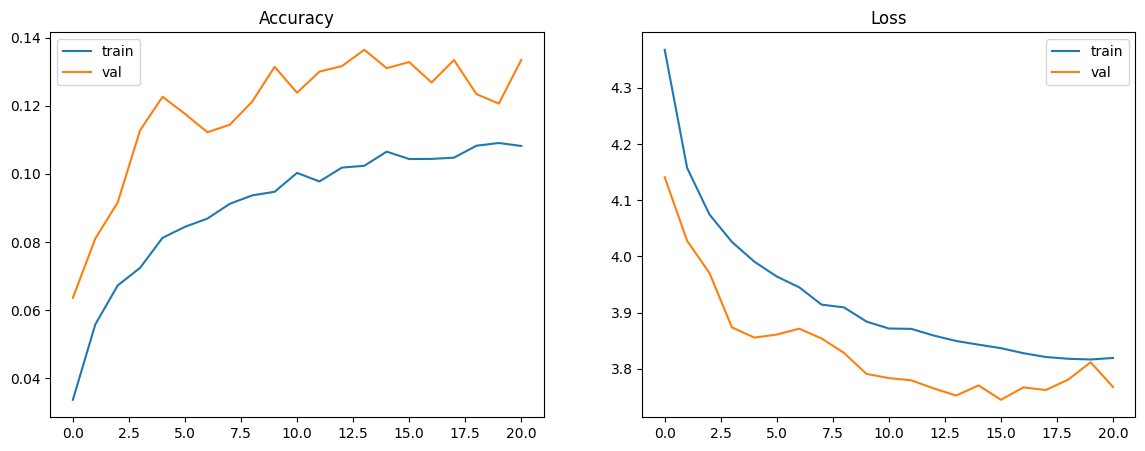

In [ ]:

def plot_training(history):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_training(history)


Evaluación Final

In [ ]:

modelo_final = load_model('mejor_modelo.h5')
score = modelo_final.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test Accuracy: {score[1]*100:.2f}%")

Test Accuracy: 13.96%


Métricas Avanzadas

In [ ]:
# MÉTRICAS AVANZADAS
y_pred = np.argmax(modelo_final.predict(X_test_flat), axis=1)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.52      0.26      0.35       100
           1       0.24      0.26      0.25       100
           2       0.08      0.05      0.06       100
           3       0.09      0.03      0.05       100
           4       0.04      0.04      0.04       100
           5       0.20      0.09      0.12       100
           6       0.13      0.13      0.13       100
           7       0.12      0.12      0.12       100
           8       0.03      0.14      0.05       100
           9       0.30      0.03      0.05       100
          10       0.33      0.01      0.02       100
          11       0.23      0.03      0.05       100
          12       0.09      0.08      0.09       100
          13       0.00      0.00      0.00       100
          14       0.07      0.03      0.04       100
          15       0.00      0.00      0.00       100
          16       0.00      0.00      0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Matriz de Confusión

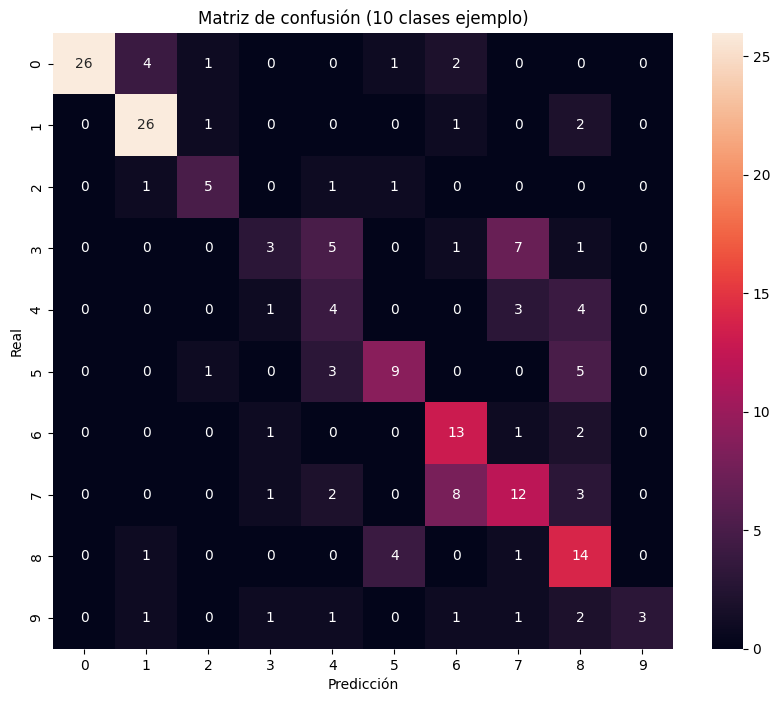

In [ ]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm[:10, :10], annot=True, fmt="d")
plt.title("Matriz de confusión (10 clases ejemplo)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


# Probando modelo con diferentes activaciones

 Paso 1: Función de evaluación con resumen de métricas


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluar_modelo(modelo, X_test, y_test, nombre="modelo"):
    y_pred = np.argmax(modelo.predict(X_test), axis=1)
    accuracy = np.mean(y_pred == y_test.flatten())
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"{nombre} → Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    return [nombre, accuracy, precision, recall, f1]


 Paso 2: Entrenar modelos con diferentes activaciones (relu, tanh y sigmoid)


In [ ]:
resultados = []

activaciones = ['relu', 'tanh', 'sigmoid']

for act in activaciones:
    print(f"\nEntrenando modelo con activación: {act}")
    modelo = crear_modelo(activation=act)
    modelo.fit(X_train_flat, y_train,
               epochs=20,
               batch_size=64,
               validation_split=0.1,
               verbose=0)  # Para evitar mucho texto
    resultados.append(evaluar_modelo(modelo, X_test_flat, y_test, nombre=f"MLP_{act}"))



Entrenando modelo con activación: relu


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MLP_relu → Accuracy: 0.1514, Precision: 0.1960, Recall: 0.1514, F1: 0.1380

Entrenando modelo con activación: tanh


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MLP_tanh → Accuracy: 0.1192, Precision: 0.0908, Recall: 0.1192, F1: 0.0857

Entrenando modelo con activación: sigmoid


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
MLP_sigmoid → Accuracy: 0.2019, Precision: 0.1928, Recall: 0.2019, F1: 0.1784


📊 Paso 3: Mostrar tabla comparativa


In [ ]:
import pandas as pd

df_resultados = pd.DataFrame(resultados, columns=['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
df_resultados


,Modelo,Accuracy,Precision,Recall,F1-Score
0,MLP_relu,0.1514,0.195984,0.1514,0.138003
1,MLP_tanh,0.1192,0.090846,0.1192,0.085714
2,MLP_sigmoid,0.2019,0.192758,0.2019,0.178445


# Probando modelo con optimizadores

In [ ]:
optimizadores = ['adam', 'sgd', 'rmsprop']
resultados_opt = []

for opt in optimizadores:
    print(f"\nEntrenando modelo con optimizador: {opt}")
    modelo = crear_modelo(activation='sigmoid', optimizer=opt)
    modelo.fit(X_train_flat, y_train,
               epochs=20,
               batch_size=64,
               validation_split=0.1,
               verbose=0)
    resultados_opt.append(evaluar_modelo(modelo, X_test_flat, y_test, nombre=f"MLP_sigmoid_{opt}"))



Entrenando modelo con optimizador: adam


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [ ]:
df_opt = pd.DataFrame(resultados_opt, columns=['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
df_opt


 # 1. Comparación con y sin Dropout

Paso 1: Crear una variante del modelo sin Dropout

In [ ]:
def crear_modelo_dropout(activation='sigmoid', optimizer='adam', use_dropout=True):
    model = Sequential()
    model.add(Dense(512, activation=activation, input_shape=(3072,)))
    if use_dropout:
        model.add(Dropout(0.3))
    model.add(Dense(256, activation=activation))
    if use_dropout:
        model.add(Dropout(0.3))
    model.add(Dense(100, activation='softmax'))

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


Paso 2: Entrenar con y sin Dropout

In [ ]:
resultados_dropout = []

for use_dropout in [True, False]:
    nombre = "MLP_sigmoid_dropout" if use_dropout else "MLP_sigmoid_nodropout"
    print(f"\nEntrenando modelo: {nombre}")
    modelo = crear_modelo_dropout(activation='sigmoid', use_dropout=use_dropout)
    modelo.fit(X_train_flat, y_train,
               epochs=20,
               batch_size=64,
               validation_split=0.1,
               verbose=0)
    resultados_dropout.append(evaluar_modelo(modelo, X_test_flat, y_test, nombre=nombre))


In [ ]:
df_dropout = pd.DataFrame(resultados_dropout, columns=['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
df_dropout


# 2. Pruebas variando batch size y learning rate

Paso 1: Probar diferentes batch sizes

Recordemos que mientras menor batch size, mayor precision deberia dar, mientras que mayor deberia haber menor presicion pero mejor estabilidad.

In [ ]:
from tensorflow.keras.optimizers import Adam

batch_sizes = [32, 64, 128]
resultados_batch = []

for bs in batch_sizes:
    print(f"\nEntrenando con batch_size = {bs}")
    modelo = crear_modelo(activation='sigmoid', optimizer=Adam(learning_rate=0.001))
    modelo.fit(X_train_flat, y_train,
               epochs=20,
               batch_size=bs,
               validation_split=0.1,
               verbose=0)
    resultados_batch.append(evaluar_modelo(modelo, X_test_flat, y_test, nombre=f"batch_{bs}"))


Paso 2: Probar diferentes learning rates

In [ ]:
learning_rates = [0.001, 0.0005, 0.0001]
resultados_lr = []

for lr in learning_rates:
    print(f"\nEntrenando con learning_rate = {lr}")
    opt = Adam(learning_rate=lr)
    modelo = crear_modelo(activation='sigmoid', optimizer=opt)
    modelo.fit(X_train_flat, y_train,
               epochs=20,
               batch_size=64,
               validation_split=0.1,
               verbose=0)
    resultados_lr.append(evaluar_modelo(modelo, X_test_flat, y_test, nombre=f"lr_{lr}"))


Tablas finales

In [ ]:
df_batch = pd.DataFrame(resultados_batch, columns=['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
df_lr = pd.DataFrame(resultados_lr, columns=['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])


# 3. Comparaciones visuales con TensorBoard

In [ ]:
import datetime

def log_tensorboard(nombre_experimento):
    log_dir = f"logs/fit/{nombre_experimento}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    return TensorBoard(log_dir=log_dir, histogram_freq=1)


In [ ]:
modelo.fit(
    X_train_flat, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[log_tensorboard('batch_64')],
    verbose=0
)


In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs/fit


# Incorporación de Gradio

In [ ]:
import gradio as gr
from PIL import Image

# Cargar el mejor modelo entrenado
modelo_gradio = load_model('mejor_modelo.h5')

# Lista de etiquetas (100 clases de CIFAR-100)
from tensorflow.keras.datasets import cifar100
_, (X_test, y_test) = cifar100.load_data(label_mode='fine')
label_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'cactus',
    'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee',
    'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup',
    'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl',
    'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard',
    'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy',
    'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail',
    'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper',
    'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train',
    'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf',
    'woman', 'worm'
]

# Función para predecir una imagen
def predecir_clase(imagen):
    imagen = imagen.resize((32, 32))
    arr = np.array(imagen).astype("float32") / 255.0
    arr_flat = arr.reshape((1, -1))
    pred = modelo_gradio.predict(arr_flat)
    clase = np.argmax(pred)
    return f"Clase predicha: {label_names[clase]}"

# Crear interfaz de Gradio
gr.Interface(
    fn=predecir_clase,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Clasificador CIFAR-100 (MLP)",
    description="Sube una imagen de 32x32 o será redimensionada automáticamente"
).launch()
